# Feels vs. Is: a two-axis bike safety model for DC

LTS tells you how a street feels. Crashes tell you what happens on it. This notebook scores both for every segment in the `ridescore_dc_basemap_2026-09-29` snapshot, then maps where they disagree.

The logic lives in `feels_vs_is.py` as plain functions. This notebook calls them in stage order and shows a checkpoint after each. See `SPEC.md` for the design and `README.md` for what the outputs mean.

Run from the repo root:

    uv run --group notebooks --with statsmodels --with requests --with scikit-learn jupyter lab

The crash fetch (Stage 3) hits DC GIS once and caches to `cache/crashes.parquet`. With the cache present the notebook runs top to bottom in about three minutes.

In [1]:
%load_ext autoreload
%autoreload 2
import json, pathlib, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import feels_vs_is as F

pd.set_option("display.width", 220, "display.max_columns", 40, "display.max_colwidth", 90)
t0 = time.time()
g0 = F.load_snapshot()
print(g0.shape, g0.crs)

(28978, 136) {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "scope"

## Stage 1: clean

One value per field per segment, with its source, so the README can state precedence: DDOT first, OSM second, class median last.

In [2]:
c = F.clean(g0)
for col in ["speed_src", "lanes_src", "aadt_src", "facility", "facility_src", "func_class", "confidence"]:
    print(f"\n== {col}\n{c[col].value_counts().to_string()}")
print("\nparallel_track", int(c.parallel_track.sum()), " door_zone", int(c.door_zone.sum()), " network km", round(c.length_m.sum() / 1000))


== speed_src
speed_src
ddot            23137
class_median     4390
osm              1451

== lanes_src
lanes_src
ddot            26716
class_median     1769
osm               493

== aadt_src
aadt_src
class_median    17318
ddot_2020       11660

== facility
facility
none         22255
separated     3426
painted       1969
sharrow        906
protected      252
buffered       170

== facility_src
facility_src
none              20960
osm_highway        3426
ddot               2176
parallel_track     1295
osm_tag            1121

== func_class
func_class
Local                 14539
Minor Arterial         5690
Collector              4119
Principal Arterial     3390
Off-street             1148
Freeway                  86
Interstate                6

== confidence
confidence
high      23904
medium     3089
low        1985

parallel_track 1295  door_zone 1628  network km 2165


## Stage 2: Feels (comfort)

`comfort_lts` follows Furth's LTS tables with Montgomery County amendments. `comfort_score` (0 to 100, higher is more comfortable) places each segment inside its level's band using volume, truck share, door zone, pavement and traffic calming. LTS v1 from the pipeline is kept for comparison on matched rows.

In [3]:
f = F.feels(c)
f["lts_v1"] = F.lts_v1(g0)
km = lambda s: (s / 1000).round(0)
print("comfort_lts, km\n", km(f.groupby("comfort_lts").length_m.sum()).to_string())
print("\nlts_v1, km (matched rows)\n", km(f.groupby("lts_v1").length_m.sum()).to_string())
print("\ncomfort_lts (rows) x lts_v1 (cols), km")
display(pd.crosstab(f.comfort_lts, f.lts_v1, values=f.length_m / 1000, aggfunc="sum").round(0))
display(pd.crosstab(f.facility, f.comfort_lts))

comfort_lts, km
 comfort_lts
1    1206.0
2     543.0
3     257.0
4     158.0

lts_v1, km (matched rows)
 lts_v1
1     76.0
2    998.0
3    243.0
4    772.0

comfort_lts (rows) x lts_v1 (cols), km


lts_v1,1,2,3,4
comfort_lts,,,,
1,48.0,785.0,148.0,171.0
2,18.0,135.0,79.0,294.0
3,6.0,78.0,15.0,154.0
4,4.0,NaN,0.0,153.0


comfort_lts,1,2,3,4
facility,,,,
buffered,48,70,52,0
none,12094,6079,2276,1806
painted,48,447,1474,0
protected,252,0,0,0
separated,3426,0,0,0
sharrow,212,513,134,47


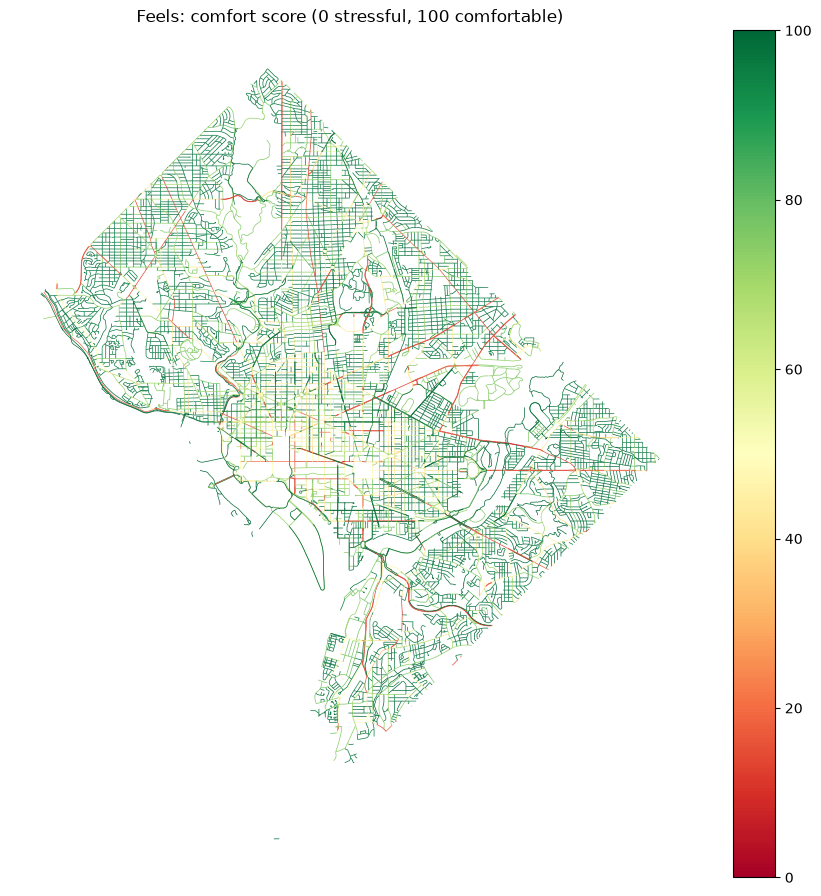

In [4]:
fig, ax = plt.subplots(figsize=(11, 11))
f.to_crs("EPSG:26985").plot(column="comfort_score", cmap="RdYlGn", linewidth=0.5, ax=ax, legend=True, vmin=0, vmax=100)
ax.set_axis_off(); ax.set_title("Feels: comfort score (0 stressful, 100 comfortable)")
plt.show()

## Stage 3: intersections and crashes

Intersections are clusters of degree 3+ nodes within 15 m (DBSCAN), so a complex junction or a track crossing counts once. Crashes are five years of bicyclist injury crashes from DC GIS layer 24. Each crash goes to an intersection cluster, a DDOT block, the nearest segment, or nowhere.

In [5]:
clusters, approaches, node_map = F.intersections(f)
print("intersection clusters", len(clusters))
print(clusters.n_approaches.value_counts().sort_index().head(8).to_string())
crashes = F.fetch_crashes()
print("\ncrashes", len(crashes), " ksi", int(crashes.ksi.sum()), " fatal", int(crashes.fatal.sum()))
print(crashes.date.dt.year.value_counts().sort_index().to_string())
crashes = F.assign_crashes(crashes, f, clusters)
print("\nassignment path\n", crashes.path.value_counts().to_string())
print("\nksi by path\n", crashes.groupby("path").ksi.sum().to_string())

intersection clusters 7672
n_approaches
2      50
3    3207
4    2229
5     317
6     612
7     537
8     266
9     135

crashes 2297  ksi 202  fatal 9
date
2021     60
2022    302
2023    383
2024    447
2025    559
2026    546

assignment path
 path
blockkey           1146
intersection        933
nearest_segment     153
unmatched            65

ksi by path
 path
blockkey           94
intersection       86
nearest_segment    14
unmatched           8


## Stage 4: Is (harm), with Empirical Bayes

A negative binomial model of crash counts on design features only (function class, facility, speed, lanes, volume percentile; for intersections, approaches, class, speed, wide approaches, separated approaches). Ward and location stay out, so the expectation comes from design rather than neighborhood. Empirical Bayes then blends each unit's own history with that expectation: `w = 1 / (1 + alpha * mu)`, `eb = w * mu + (1 - w) * observed`.

Per segment, `harm_score` is the length-weighted percentile of the worse of its block rate and its worst end-intersection rate. 90 means the worst 10 percent of network length.

In [6]:
fit = F.harm(f, clusters, approaches, crashes)
print("block model:", fit["method_block"], "alpha", round(fit["alpha_block"], 2), "| intersection model:", fit["method_int"], "alpha", round(fit["alpha_int"], 2), "| years", round(fit["years"], 2))
bu, iu = fit["blocks"], fit["intersections"]
print("blocks", len(bu), "with crashes", int((bu.crashes > 0).sum()), "| intersections", len(iu), "with crashes", int((iu.crashes > 0).sum()))
print("\nTop blocks by EB rate")
display(bu.sort_values("eb_per_km_yr", ascending=False).head(10)[["name", "length_m", "facility", "speed_mph", "lanes", "crashes", "ksi", "mu", "eb", "eb_per_km_yr"]].round(2))
print("Top intersections by EB rate")
display(iu.sort_values("eb_per_yr", ascending=False).head(10)[["names", "n_approaches", "speed_mph", "crashes", "ksi", "mu", "eb", "eb_per_yr"]].round(2))
h = F.score_harm(f, fit, node_map)
print(h.harm_driver.value_counts().to_string())

block model: negative_binomial alpha 1.07 | intersection model: negative_binomial alpha 3.8 | years 5.0
blocks 15420 with crashes 922 | intersections 7672 with crashes 657

Top blocks by EB rate


,name,length_m,facility,speed_mph,lanes,crashes,ksi,mu,eb,eb_per_km_yr
unit,,,,,,,,,,
f217f5fbccb8b5787492be2131bd04a7,14th Street Northwest,159.47,protected,25,3,9,1,0.34,2.62,3.29
c56999ae9ec73fd01bc0bc2b45ef4557,15th Street Northwest,205.60,none,20,4,7,2,0.60,3.08,3.00
a7cf3495e3dfcf737207d6a5ebd4136f,9th Street Northwest,147.31,none,25,3,7,0,0.36,2.21,3.00
b4c64b5b0b957cbc600f374a14b79b00,K St NW,84.77,none,20,4,4,0,0.31,1.24,2.92
4519b88e041b24532d9992f02c03d3d9,K St NW,174.15,none,20,3,6,0,0.54,2.53,2.91
c92d5ba6f7ea0e2ee8d2e174f28bde32,K St NW,126.38,none,20,2,5,0,0.41,1.80,2.85
97178350e8b252e0e4c408ccefb0d72c,7th Street Northwest,151.05,sharrow,20,3,5,0,0.51,2.10,2.78
bba5552a35b6dad551182ac9815ba800,14th Street Northwest,122.84,none,20,4,4,0,0.46,1.63,2.66
59326cd48eca1254535cfe90f46c005c,New Jersey Avenue Southeast Cycleway,114.29,protected,20,2,5,0,0.30,1.43,2.50


Top intersections by EB rate


,names,n_approaches,speed_mph,crashes,ksi,mu,eb,eb_per_yr
int_id,,,,,,,,
2801,9th Street Northwest & Rhode Island Avenue Northwest,11,25,7,1,0.50,4.76,0.95
995,U Street Northwest & 14th Street Northwest,7,20,5,0,0.48,3.39,0.68
2669,H Street Northwest & 11th Street Northwest,10,25,5,0,0.41,3.20,0.64
6840,Irving Street Northwest & 14th Street Northwest,4,25,5,1,0.34,2.95,0.59
5456,North Capitol Street Northwest & New York Avenue Northwest,8,25,6,0,0.23,2.91,0.58
2887,P Street Northeast & Florida Avenue Northeast,6,25,6,0,0.23,2.91,0.58
989,R Street Northwest & 14th Street Northwest,11,25,4,1,0.50,2.79,0.56
2647,7th Street Northwest & Rhode Island Avenue Northwest,4,25,5,3,0.28,2.71,0.54
307,Bladensburg Road Northeast & Maryland Avenue Northeast,14,30,7,1,0.16,2.71,0.54


harm_driver
block           17098
intersection    11880


## Stage 5: gap and reasons

Where Feels and Is disagree. The harm threshold is tuned so `hidden_danger` is a short list, about 5 percent of network length.

In [7]:
g = F.gap(h)
print("thresholds", F.THRESHOLDS)
print("length share %\n", (g.groupby("gap_class").length_m.sum() / g.length_m.sum() * 100).round(1).to_string())
cols = ["name", "comfort_lts", "comfort_score", "harm_score", "harm_driver", "crashes_5yr", "ksi_5yr", "node_crashes_5yr", "facility", "reasons"]
for cls in ["hidden_danger", "fix_first"]:
    print(f"\nTop {cls} (one row per block)")
    display(g[g.gap_class == cls].sort_values("harm_score", ascending=False).drop_duplicates("unit").head(15)[cols])

thresholds {'harm_high': 92.0, 'harm_low': 40.0}
length share %
 gap_class
calm               38.3
fix_first           3.0
hidden_danger       4.8
middle             52.4
scary_but_quiet     1.4

Top hidden_danger (one row per block)


,name,comfort_lts,comfort_score,harm_score,harm_driver,crashes_5yr,ksi_5yr,node_crashes_5yr,facility,reasons
3328,14th Street Northwest,1,93.1,100.0,block,9,1,0,protected,"protected lane, 3 lanes at 25 mph; 9 injury crashes on this block since Oct 2021 (1 se..."
21509,15th Street Northwest Cycle Track,1,100.0,100.0,block,7,2,0,separated,separated two-way track; 7 injury crashes on this block since Oct 2021 (2 serious)
26502,9th St NW,1,100.0,100.0,intersection,1,0,7,separated,separated two-way track; 7 injury crashes at 9th Street Northwest & Rhode Island Avenu...
26501,9th St NW,1,100.0,100.0,intersection,0,0,7,separated,separated two-way track; 7 injury crashes at 9th Street Northwest & Rhode Island Avenu...
13755,9th Street Northwest,2,72.9,99.9,block,7,0,1,none,"mixed traffic, 3 lanes at 25 mph, beside a separate track; 7 injury crashes on this bl..."
8722,K Street Northwest,2,70.4,99.9,block,6,0,0,none,"mixed traffic, 3 lanes at 20 mph, beside a separate track; 6 injury crashes on this bl..."
28299,K St NW,1,100.0,99.9,block,4,0,0,separated,separated one-way track; 4 injury crashes on this block since Oct 2021 (0 serious); cr...
26206,14th Street Northwest,1,100.0,99.9,intersection,4,0,5,separated,separated one-way track; 5 injury crashes at U Street Northwest & 14th Street Northwes...
20259,14th Street Northwest,2,73.1,99.9,intersection,1,0,5,painted,"4 lanes at 25 mph, painted lane; 5 injury crashes at Irving Street Northwest & 14th St..."
24963,Irving Street Northwest,2,71.2,99.9,intersection,1,0,5,none,"mixed traffic, 1 lane at 25 mph; 5 injury crashes at Irving Street Northwest & 14th St..."



Top fix_first (one row per block)


,name,comfort_lts,comfort_score,harm_score,harm_driver,crashes_5yr,ksi_5yr,node_crashes_5yr,facility,reasons
24787,Q Street Northwest,3,42.9,100.0,intersection,0,0,7,painted,"1 lane at 25 mph, painted lane beside parked cars; 7 injury crashes at 9th Street Nort..."
12394,9th Street Northwest,3,49.4,100.0,intersection,0,0,7,none,"mixed traffic, 4 lanes at 25 mph, beside a separate track; 7 injury crashes at 9th Str..."
9261,Rhode Island Avenue Northwest,3,43.2,100.0,intersection,0,0,7,none,"mixed traffic, 4 lanes at 25 mph; 7 injury crashes at 9th Street Northwest & Rhode Isl..."
22090,15th Street Northwest,3,51.8,100.0,block,7,2,0,none,"mixed traffic, 4 lanes at 20 mph, beside a separate track; 7 injury crashes on this bl..."
9260,9th Street Northwest,3,49.4,100.0,intersection,0,0,7,none,"mixed traffic, 4 lanes at 25 mph, beside a separate track; 7 injury crashes at 9th Str..."
9263,Rhode Island Avenue Northwest,3,43.2,100.0,intersection,1,0,7,none,"mixed traffic, 5 lanes at 25 mph; 7 injury crashes at 9th Street Northwest & Rhode Isl..."
12393,Q Street Northwest,3,36.9,100.0,intersection,0,0,7,painted,"1 lane at 25 mph, painted lane beside parked cars; 7 injury crashes at 9th Street Nort..."
15089,K Street Northwest,3,44.4,99.9,block,4,0,2,none,"mixed traffic, 4 lanes at 20 mph, beside a separate track; 4 injury crashes on this bl..."
24762,H Street Northwest,3,50.1,99.9,intersection,0,0,5,none,"mixed traffic, 5 lanes at 25 mph; 5 injury crashes at H Street Northwest & 11th Street..."
23947,U Street Northwest,3,44.2,99.9,intersection,1,0,5,none,"mixed traffic, 5 lanes at 20 mph; 5 injury crashes at U Street Northwest & 14th Street..."


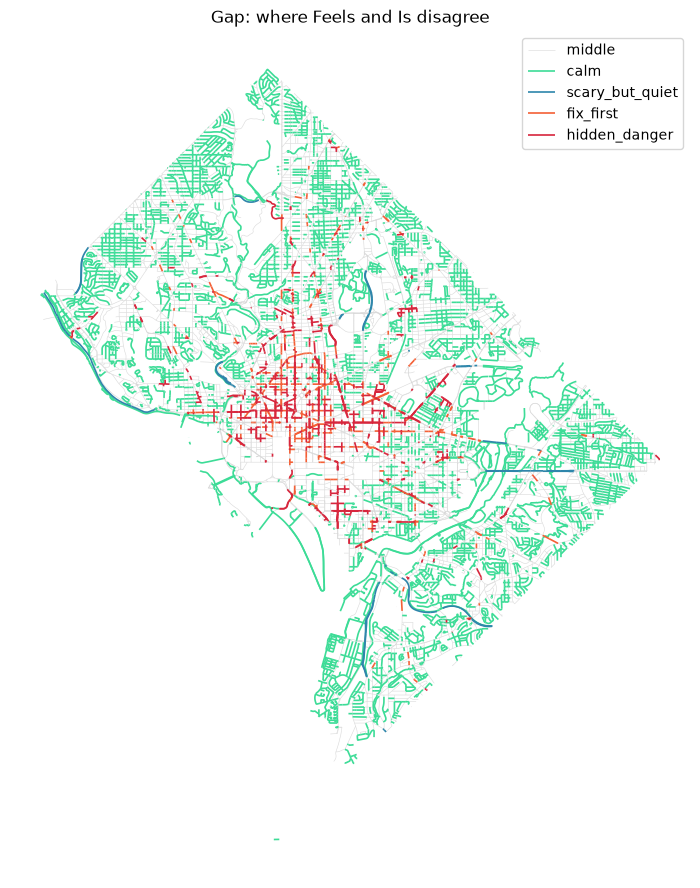

In [8]:
fig, ax = plt.subplots(figsize=(11, 11))
colors = {"hidden_danger": "#d7263d", "fix_first": "#f46036", "scary_but_quiet": "#2e86ab", "calm": "#3ddc97", "middle": "#d9d9d9"}
gm = g.to_crs("EPSG:26985")
for cls in ["middle", "calm", "scary_but_quiet", "fix_first", "hidden_danger"]:
    sub = gm[gm.gap_class == cls]
    if len(sub):
        sub.plot(ax=ax, color=colors[cls], linewidth=0.4 if cls == "middle" else 1.2, label=cls)
ax.legend(); ax.set_axis_off(); ax.set_title("Gap: where Feels and Is disagree")
plt.show()

## Stage 6: results

One row per snapshot segment, keyed by `osm_u`, `osm_v`, `osm_key`, `snapshot_date`.

In [9]:
res = F.results(g, pathlib.Path("feels_vs_is_results.parquet"))
print(res.shape, "| nulls:", res.isna().sum()[lambda s: s > 0].to_dict())
res.head()

(28978, 27) | nulls: {'lts_v1': 1399, 'dc_blockkey': 2352}


,osm_u,osm_v,osm_key,snapshot_date,comfort_score,comfort_lts,kid_ok,harm_score,harm_driver,crashes_5yr,ksi_5yr,node_crashes_5yr,node_ksi_5yr,death_risk_if_struck,gap_class,reasons,confidence,speed_mph,speed_src,lanes,lanes_src,facility,facility_src,door_zone,parallel_track,lts_v1,dc_blockkey
0,49184747,49198976,0,2026-09-29,70.2,2,False,67.0,block,0,0,0,0,0.120,middle,"mixed traffic, 2 lanes at 25 mph; design matches blocks that see crashes; crossed by 3...",high,25,ddot,2,ddot,none,none,False,False,4,03c467574df701837f497aac38223294
1,49184747,937305437,0,2026-09-29,70.2,2,False,67.0,block,0,0,0,0,0.120,middle,"mixed traffic, 2 lanes at 25 mph; design matches blocks that see crashes; crossed by 3...",high,25,ddot,2,ddot,none,none,False,False,4,03c467574df701837f497aac38223294
2,49184747,1241590338,0,2026-09-29,96.6,1,True,43.4,intersection,0,0,0,0,0.068,middle,"mixed traffic, 2 lanes at 20 mph",high,20,ddot,2,ddot,none,none,False,False,2,1075e5b5ca48ab92448551a35282c48a
3,49185131,49749154,0,2026-09-29,96.6,1,True,65.8,intersection,0,0,0,0,0.068,middle,"mixed traffic, 1 lane at 20 mph; crossed by 69 intersections per km",high,20,ddot,1,ddot,none,none,False,False,2,3700cad5a71a9812e0da96d742fb263d
4,49198976,3900798862,0,2026-09-29,70.2,2,False,66.3,block,0,0,0,0,0.120,middle,"mixed traffic, 2 lanes at 25 mph; design matches blocks that see crashes",high,25,ddot,2,ddot,none,none,False,False,4,9dcb7cf880e23b2721919cc1d000c453


## Validation

Train on crashes before 2025, test on 2025 to 2026. Rank blocks by each method and ask what share of test-period injury and serious crashes fall in the worst 10 percent of block length (or the worst 10 percent of intersections). Methods (a) to (c) are design-only. Method (d) uses crash history, so it measures persistence rather than design.

train crashes 1192 | test crashes 1105 | test ksi 100


,unit,method,injury_capture,ksi_capture
0,blocks,a. LTS v1 (design only),0.128,0.120
1,blocks,b. Feels comfort (design only),0.204,0.140
2,blocks,c. Harm model expectation mu (design only),0.364,0.340
3,blocks,d. Empirical Bayes with train history,0.435,0.380
4,intersections,a. LTS v1 (design only),0.126,0.022
5,intersections,b. Feels comfort (design only),0.182,0.174
6,intersections,c. Harm model expectation mu (design only),0.292,0.348
7,intersections,d. Empirical Bayes with train history,0.427,0.391


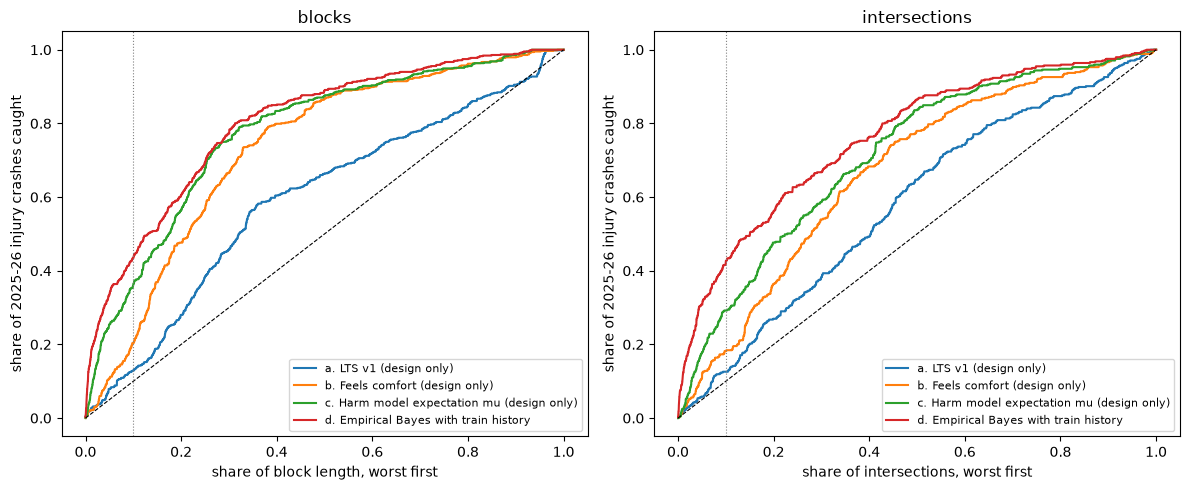

In [10]:
board, curves = F.validate(f, clusters, approaches, node_map, crashes)
print("train crashes", board.attrs["train_crashes"], "| test crashes", board.attrs["test_crashes"], "| test ksi", board.attrs["test_ksi"])
display(board)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, kind in zip(axes, ["blocks", "intersections"]):
    for (k, name), (w, hh, hk) in curves.items():
        if k == kind:
            ax.plot(w, hh, label=name)
    ax.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax.axvline(0.1, color="gray", lw=0.8, ls=":")
    ax.set_xlabel("share of " + ("block length" if kind == "blocks" else "intersections") + ", worst first"); ax.set_ylabel("share of 2025-26 injury crashes caught")
    ax.set_title(kind); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Map

Exports `cache/web/segments.geojson`, `cache/web/intersections.geojson` and `cache/web/stories.json` for the MapLibre page in `web/index.html`. The page is published from the fork's `gh-pages` branch at [bryceob13.github.io/ridescoredc-models](https://bryceob13.github.io/ridescoredc-models/).

In [11]:
print(F.export_web(g, fit))
stories = F.stories(g, fit, crashes)
json.dump(stories, open(F.CACHE / "web" / "stories.json", "w"), indent=1)
for s in stories:
    print("-", s["title"], "|", s["sub"])
print(f"\ntotal {time.time() - t0:.0f}s")

{'segments': 28978, 'intersections': 657}
- 14th Street Northwest: hidden danger | LTS 1, comfort 93, 9 injury crashes on one block since Oct 2021 (1 serious)
- 9th Street Northwest & Rhode Island Avenue Northwest: worst intersection | 7 injury crashes since Oct 2021 (1 serious), 0.5 expected for its design
- 21st & I St NW: two blocks from here | 3 injury crashes within 120 m since Oct 2021 (1 serious). The July 2022 truck death is not recorded as a bicyclist fatality in this layer
- Connecticut Ave NW: the lanes that were dropped | 7 injury crashes on these blocks since Oct 2021; mostly LTS 4. DDOT shelved its protected lanes in April 2024

total 137s


## Stage 7: trend, changes on the ground, street and ward reports

Trend compares each unit's injury crash rate since Jan 2025 with Oct 2021 to Dec 2024, relative to the citywide change. DDOT ProTrack project lines (bike lanes, speed management, safety, signals, streetscape since 2019) are matched to segments by route and measure, else by proximity, so each report can list what was built and the crash rate before and after. `reports.json` feeds the search and ward views on the map.

In [12]:
ward = pd.read_parquet(F.SNAPSHOT, columns=["dc_WARD_ID"])["dc_WARD_ID"].reset_index(drop=True)
g = F.trends(g, crashes, fit, node_map)
print("citywide after/before rate ratio:", round(g.attrs["base_ratio"], 2))
print(g.trend.value_counts().to_string())
projects, seg_project = F.load_projects(g)
g = F.attach_projects(g, projects, seg_project)
print("\nprojects", len(projects), "| segments with a completed change", int(g.changed.notna().sum()), "| planned or in progress", int(g.planned.notna().sum()))
print(g.changed_what.value_counts().to_string())
rep = F.street_reports(g, fit, approaches, crashes, ward, projects=projects, seg_project=seg_project)
json.dump(rep, open(F.CACHE / "web" / "reports.json", "w"), separators=(",", ":"))
print("\nreports: streets", len(rep["streets"]), "wards", len(rep["wards"]))
print(F.export_web(g, fit, ward=ward))
r = rep["streets"]["15th Street Northwest"]
print("\n15th Street Northwest:", r["crashes"], "crashes, trend", r["trend"], f"({r['before_per_yr']}/yr -> {r['after_per_yr']}/yr, {r['trend_ratio']}x the citywide change)")
for c in r["changes"][:4]:
    print(" -", c["what"], c["status"], c.get("completed"), c["from"], "to", c["to"], "| before", c.get("before_per_yr"), "after", c.get("after_per_yr"), "per yr")

citywide after/before rate ratio: 1.73
trend
too few     28106
falling?      370
rising?       236
flat          153
rising         76
falling        37



projects 340 | segments with a completed change 4192 | planned or in progress 1294
changed_what
bike lane project                  2799
speed management                    641
bike markings                       302
safety maintenance                  277
streetscape                         123
safety improvement                   30
highway safety improvement           17
bike and pedestrian improvement       3



reports: streets 1047 wards 8


{'segments': 28978, 'intersections': 657}

15th Street Northwest: 55 crashes, trend flat (8.6/yr -> 15.5/yr, 1.04x the citywide change)
 - bike lane project completed 2021-11 Constitution Ave Nw to Pennsylvania Ave Nw & E St Nw | before None after 0.41 per yr
 - bike lane project completed 2021-11 Madison Dr Nw to Constitution Ave Nw | before None after 0.21 per yr
 - bike markings completed 2019-06 Harvard St Nw to Irving St Nw | before None after 0.27 per yr
 - bike markings completed 2019-06 Euclid St Nw to Fuller St Nw | before None after 0.55 per yr
